# Resultados

In [140]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from scipy.stats import chi2
from numpy import exp, linspace, random, std, mean, log10, ceil, diag, sqrt, log, sum, power,array, zeros_like

In [141]:
# función exponencial usada para el ajuste
def exponencial(x, a, b):
    '''esta funcion retorna la funcion exponencial cuando
     se ingresa el array de la variable independiente y los valores
     de amplitud y el parametro que acompaña el exponnete'''
    
    return a*exp(b*x)

In [142]:
#función lineal para el método de mínimos cuadrados
def linealizada(x, a, b):
    ''' 
    Esta funcion retorna la linealizacion de la funcion del 
    voltaje vs corriente en un diodo. Log(I) = a V + b '''

    return x * a + b

In [143]:
#función para calcular la incertidumnbre Kb 

def delkb(a, T, da, dT):
    e = 1.602176634e-19
    n = 1.91
    kb = (e / n) * (1 / (a * T))
    df = kb * ((da/a)**2 + (dT/T)**2)**0.5
    return df

## Datos delimitados de a 0.005

In [144]:
df =pd.read_csv('Datos/datos_de_fisica_experimental.csv', delimiter=';') #Importación de los datos

In [145]:
df['Corriente'] = df['Corriente']* 1e-4 #Pasamos los datos a la escala de mA

In [146]:
#Renombramos variables para las gráficas
I = df['Corriente']
V = df['Voltaje']
mejor_valor, cov = curve_fit(exponencial, V, I)

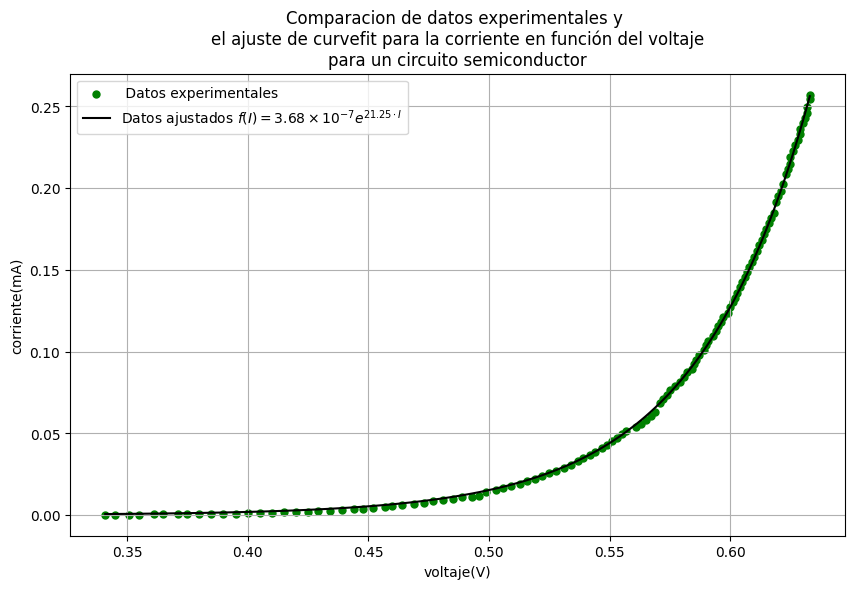

In [147]:
# Gráfica de comparación del ajuste con los dato experimentales

Ia =exponencial(V, mejor_valor[0], mejor_valor[1])
plt.figure(figsize=(10,6))
plt.title('Comparacion de datos experimentales y \nel ajuste de curvefit para la corriente en función del voltaje\npara un circuito semiconductor')
plt.scatter(V, I, label = ' Datos experimentales', s = 25,c = 'green')
plt.plot(V, Ia,c= 'black', 
         label = f"Datos ajustados $f(I) = {mejor_valor[0]*1e7:.2f} \\times 10^{{-7}} e^{{{mejor_valor[1]:.2f} \\cdot I}}$")
plt.ylabel( 'corriente(mA)')
plt.xlabel('voltaje(V)')
plt.legend()
plt.grid()
plt.savefig('Articulo/Imagenes/datos_0.005.jpg')
plt.show()

In [148]:
display(diag(cov)) # Varianzas de los parámetros

array([1.32164169e-16, 2.56269288e-03])

### Test de bondad de chicuadrado

5
0.0001 0.25720000000000004
[1.0000e-04 5.1520e-02 1.0294e-01 1.5436e-01 2.0578e-01 2.5720e-01]
[1.0000e-04 5.1520e-02 1.0294e-01 1.5436e-01 2.0578e-01 2.5720e-01]
[57. 18. 17. 14. 15.]
[57. 19. 17. 13. 15.]
Chi cuadrado = 0.12955465587044535


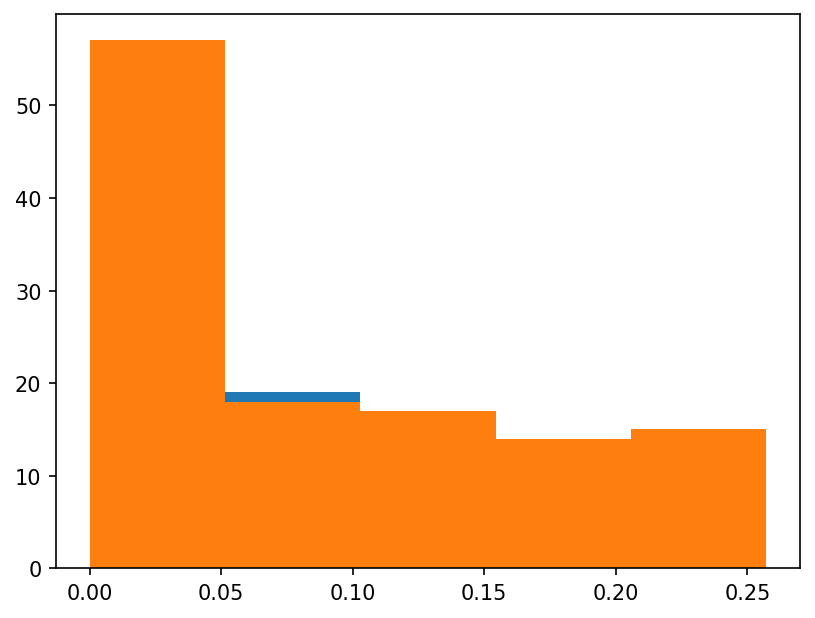

In [149]:
nbin = int(1 + 3.322 * log10(101)) - 2
print(nbin)

ymin1 = min(I)
ymin2 = min(Ia)
ymin = ymin2 if ymin1 > ymin2 else ymin1

ymax1 = max(I)
ymax2 = max(Ia)
ymax = ymax1 if ymax1 > ymax2 else ymax2
print(ymin, ymax)

plt.figure(dpi=150)
naj, baj, paj = plt.hist(Ia, bins=nbin, range=(ymin, ymax))
n, b, p = plt.hist(I, bins=nbin, range=(ymin, ymax))

print(b)
print(baj)
print(n)

def chi_sqr(dathistexp, dathistaj):
    return sum(((dathistexp - dathistaj) ** 2) / dathistaj)

print(naj)
print('Chi cuadrado =', chi_sqr(n, naj))

## Datos delimitados de a 0.01

In [150]:
datos = pd.read_csv("Datos/datos de a 0.01.csv", delimiter=';') # Importación de datos

In [151]:
datos # mostramos el dataframe

,voltaje,corriente
0,411,13
1,420,18
2,439,23
3,447,29
4,456,38
...,...,...
82,666,5511
83,666,5601
84,667,5960
85,667,5779


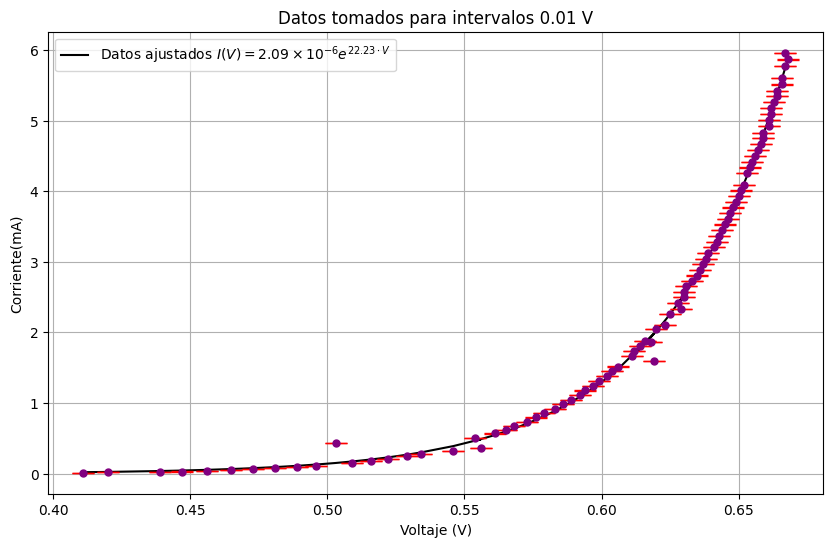

In [152]:
#Convertimos a las unidades correctas
I = datos['corriente']* 1e-3
V = datos['voltaje']* 1e-3

#Realizamos el ajuste
mejor_valor, cov = curve_fit(exponencial, V, I, sigma = 1e3)
a = mejor_valor[0]
b = mejor_valor[1]

Ia = exponencial(V, a, b)

#Gráfica de comparación de los datos experimentales y el ajuste
plt.figure(figsize=(10,6))
plt.title('Datos tomados para intervalos 0.01 V')
# plt.scatter(V, I, c = 'purple', s = 25, label = 'Datos experimentales')
plt.plot(V, Ia, c = 'black', 
         label = f"Datos ajustados $I(V) = {a*1e6:.2f} \\times 10^{{-6}} e^{{{b:.2f} \\cdot V}}$")
plt.errorbar(V,I,yerr=1e-3,fmt='.',ms= 10,capsize=8,ecolor='r',color='purple')
plt.xlabel('Voltaje (V)')
plt.ylabel('Corriente(mA)')
plt.grid()
plt.legend()
plt.savefig('Articulo/Imagenes/datos_0.01.jpg')
plt.show()

In [153]:
print(cov) # Imprimimos la matriz de covarianza

[[ 4.26110396e-14 -3.12594931e-08]
 [-3.12594931e-08  2.29456961e-02]]


In [154]:
print(a*1e8)

208.69531813729532


### Test de bondad de chicuadrado

5
0.013000000000000001 5.96
[0.013  1.2024 2.3918 3.5812 4.7706 5.96  ]
[0.013  1.2024 2.3918 3.5812 4.7706 5.96  ]
[30. 15. 15. 14. 13.]
[30. 14. 16. 13. 14.]
Chi cuadrado = 0.2822802197802198


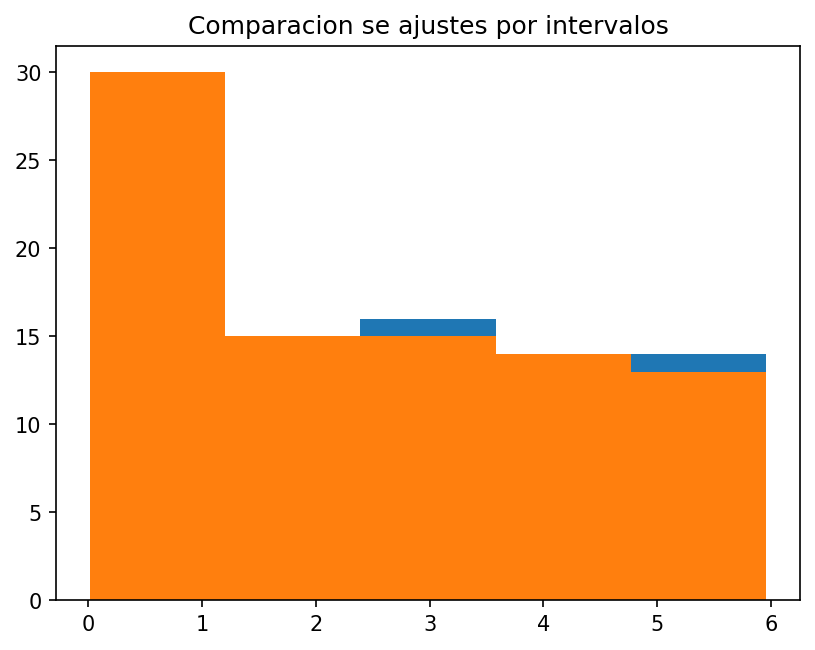

In [155]:
nbin = int(1 + 3.322 * log10(101)) - 2
print(nbin)

ymin1 = min(I)
ymin2 = min(Ia)
ymin = ymin2 if ymin1 > ymin2 else ymin1

ymax1 = max(I)
ymax2 = max(Ia)
ymax = ymax1 if ymax1 > ymax2 else ymax2
print(ymin, ymax)

plt.figure(dpi=150)
plt.title('Comparacion se ajustes por intervalos')
naj, baj, paj = plt.hist(Ia, bins=nbin, range=(ymin, ymax))
n, b, p = plt.hist(I, bins=nbin, range=(ymin, ymax))


print(b)
print(baj)
print(n)

def chi_sqr(dathistexp, dathistaj):
    return sum(((dathistexp - dathistaj) ** 2) / dathistaj)

print(naj)
print('Chi cuadrado =', chi_sqr(n, naj))

In [156]:
gl = nbin-2-1
print(gl)

valor_critico = 5
print(0.73<5)


2
True


In [157]:
#Importamos el parámetro b obtenido del ajuste y luego extraemso la varianza correspondiente 
b = mejor_valor[1]
sigma_b = sqrt(diag(cov)[1])

In [158]:
#Cálculo de la constante de Boltzman a partir del párametro b
T = (23.8 + 273.15)
e = 1.602176634e-19
n = 1.91
v = e / (T * n)
kb = v/b
print(kb)

#Calculo de la incertidumbre
in_kb = delkb(b, T, sigma_b, 0.1)

print(f'el valor de kb es ({round(kb*1e23,2)}+/- {round(in_kb*1e23,2)})')

1.2707031869095175e-23
el valor de kb es (1.27+/- 0.01)


## Datos delimitados de a 0.05

In [159]:
#Importamos los datos del ajuste lineal
datos1 = pd.read_csv('Datos/datos para datos tomados de a 0.05v.csv',delimiter= ';')

#convertimos  a las unidades correctas y luego imprimimos para mostrar
datos1 = datos1*1e-3
display(datos1)

,voltaje,corriente,voltaje 1,corriente 1,voltaje 2,corriente 2
0,0.400,0.002,0.351,0.002,0.351,0.002
1,0.446,0.038,0.400,0.010,0.400,0.010
2,0.496,0.129,0.448,0.039,0.446,0.039
3,0.528,0.275,0.482,0.091,0.489,0.111
4,0.550,0.438,0.523,0.244,0.523,0.245
5,0.565,0.667,0.555,0.492,0.550,0.447
6,0.586,0.943,0.570,0.686,0.570,0.689
7,0.598,1.235,0.587,0.970,0.585,0.968
8,0.609,1.542,0.600,1.273,0.600,1.272
9,0.618,1.871,0.611,1.592,0.610,1.592


In [160]:
#importamos los datos de corriente y voltaje
I = datos1['corriente'].dropna()
V = datos1['voltaje'].dropna()
I1 = datos1['corriente 1']
V1 = datos1['voltaje 1']
I2 = datos1['corriente 2']
V2 = datos1['voltaje 2']

#realizamos el ajuste lineal
mejor_valor, cov = curve_fit(linealizada,V, log(I))
mejor_valor1, cov1 = curve_fit(linealizada, V1, log(I1))
mejor_valor2, cov2 = curve_fit(linealizada, V2, log(I2))

#extraemos el valor de los párametros 
a = mejor_valor[0]
b = mejor_valor[1]
a1 = mejor_valor1[0]
b1 = mejor_valor1[1]
a2 = mejor_valor2[0]
b2 = mejor_valor2[1]

#extraemos los datos del ajuste
L1 = linealizada(V, a, b)
L2 = linealizada(V1, a1, b1)
L3 = linealizada(V2, a2, b2)

In [161]:
display(cov, cov1, cov2) #imprimimos las matrices de covarianza

array([[ 1.23337361, -0.73814474],
       [-0.73814474,  0.44857904]])

array([[ 0.14986115, -0.08813198],
       [-0.08813198,  0.05305269]])

array([[ 0.16874053, -0.09924244],
       [-0.09924244,  0.05974462]])

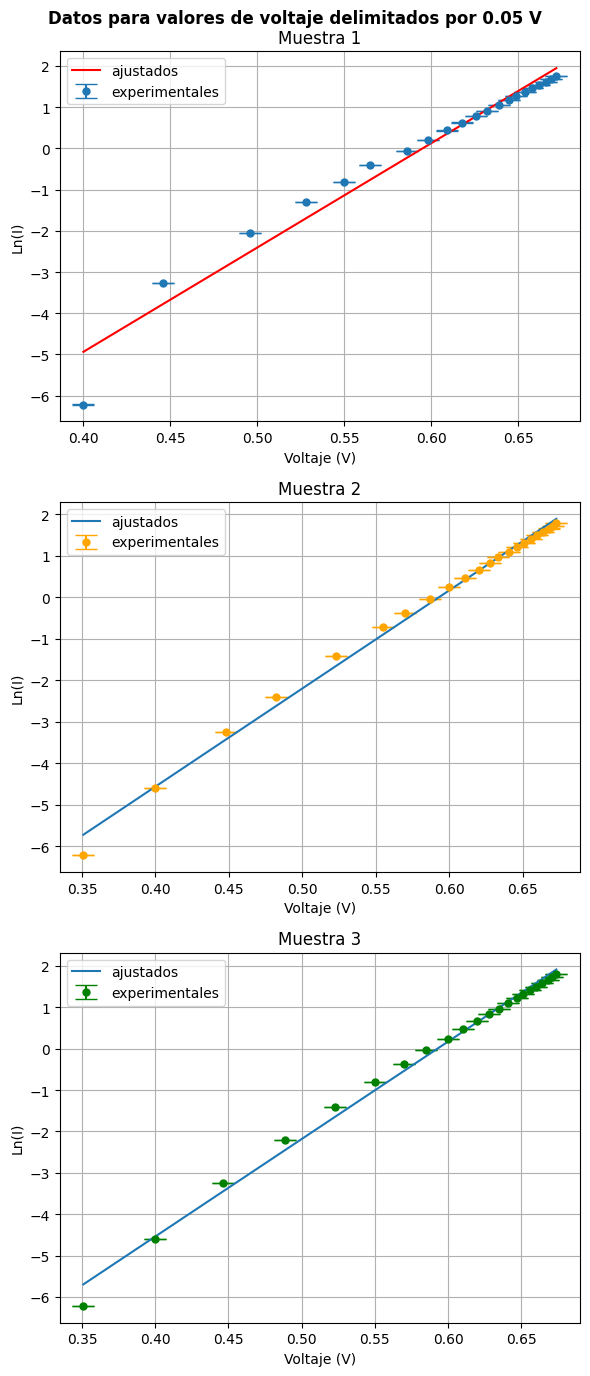

In [162]:

#Gráficamos la comparación de los tres ajustes
fig, axs = plt.subplots(3, 1 ,figsize=(6,14))  
fig.suptitle('Datos para valores de voltaje delimitados por 0.05 V', fontweight = 'bold')

# --- Gráfica 1 ---

axs[0].errorbar(V, log(I),yerr=1e-3,fmt='.',ms= 10,capsize=8, label = 'experimentales')
axs[0].plot(V, L1, label = 'ajustados', color = 'red')
axs[0].set_title("Muestra 1")
axs[0].set_xlabel("Voltaje (V)")
axs[0].set_ylabel("Ln(I)")
axs[0].legend()
axs[0].grid(True)

# --- Gráfica 2 ---,
axs[1].errorbar(V1, log(I1),yerr=1e-3,fmt='.',ms= 10,capsize=8, color='orange', label = 'experimentales')
axs[1].plot(V1, L2, label = 'ajustados')
axs[1].set_title("Muestra 2")
axs[1].set_xlabel("Voltaje (V)")
axs[1].set_ylabel("Ln(I)")
axs[1].legend()
axs[1].grid(True)

# --- Gráfica 3 ---
axs[2].errorbar(V2, log(I2), yerr=1e-3,fmt='.',ms= 10,capsize=8 , color='green', label = 'experimentales')
axs[2].plot(V2, L3, label = 'ajustados')
axs[2].set_title("Muestra 3")
axs[2].set_xlabel("Voltaje (V)")
axs[2].set_ylabel("Ln(I)")
axs[2].legend()
axs[2].grid(True)

plt.savefig('Articulo/Imagenes/datos_0.05.jpg')
plt.tight_layout() 
plt.show()

### Cálculo de kb a partir del ajuste

In [163]:
#Calculo de Kb 
T = 23.4 + 273.15
kb1 = e/(a * T * n )
kb2 = e/(a1 * T * n )
kb3 = e/(a2 *T * n )

da1 = sqrt(diag(cov)[0])
da2 = sqrt(diag(cov1)[0])
da3 = sqrt(diag(cov2)[0])

dT = 0.1
In1 = delkb(a, T, da1,  dT )
In2 = delkb(a1, T, da2,  dT )
In3 = delkb(a2, T, da3,  dT )

kb = array([kb1, kb2, kb3])
N = len(kb)
# Incertidumbre por dispersión
sigma_stat = std(kb, ddof=1) / sqrt(N)

# Incertidumbre propagada
sigma_prop = sqrt(In1**2 + In2**2 + In3**2) / N

# Incertidumbre total
In = sqrt(sigma_stat**2 + sigma_prop**2)

#imprimo kb individulaes 
print(kb1, In1, kb2, In2, kb3, In3)
# imprimo el valor de Kb con su incertidumbre estándar
print(f'el valor de la constante de Boltzman es \n K_b =({mean(kb)*1e23:.2f} +/- { In* 1e23 :.2f} )10^-23')


1.1181133365856267e-23 4.908544083838327e-25 1.1964240766780486e-23 1.9594211821912245e-25 1.2010397968263131e-23 2.0952051869795726e-25
el valor de la constante de Boltzman es 
 K_b =(1.17 +/- 0.03 )10^-23


### Cálculo de R cuadrado

In [164]:
#defino la función para calcular el párametro R^2
def r2 (L, y):
    '''Esta funcion retorna los valores del parametro r cuadrado
    para una funciion lineal ajuastada a unos datos y
    
    Parametro:
    L = array con los valores de el ajuste
    y = array con los valores observados
    
    Salida:
    Valor del r cuadrado
    '''

    sres = sum(power(y- L, 2))
    stot = sum(power(y - mean(y), 2))
    return 1 - (sres / stot)

In [165]:
#Calculo de los R^2
r2_1 = r2(L1, log(I))
r2_2 = r2(L2, log(I1))
r2_3 = r2(L2, log(I2))

In [166]:
#Imprimimos los valores de R^2
print(r2_1, r2_2, r2_3)


0.9646780933919178 0.9946665447927159 0.9935803210888575
